# 06 — HIP-4 pricing from BTC/HL-perp (theo vs actual)

The HIP-4 binary `BTC > 80,930 by 2026-05-06 06:00 UTC` is a **digital
cash-or-nothing call** on BTC. If we believe BTC log-returns are roughly
Gaussian under the risk-neutral measure, the fair value of the YES leg is

$$P_\mathrm{YES}(t) \;=\; \Pr\!\big(S_T > K \mid S_t\big) \;=\; \Phi(d_2),$$

with

$$d_2 \;=\; \frac{\ln(S_t/K) + (r-\tfrac12 \sigma^2)(T-t)}{\sigma\sqrt{T-t}}.$$

For an on-chain perp with no real risk-free rate and a holding horizon of a
few hours, the drift term is dominated by funding/carry; we set $r=0$ here
(the carry contribution to a 1-day binary is ~10⁻⁴ — well below quoted
spread). What's left is two inputs:

- **$S_t$**: HL BTC perp mid (closest to the oracle that settles the binary).
- **$\sigma$**: realized vol of HL perp log-returns over a rolling window.

We then plot the theo $\Phi(d_2)$ on the same time axis as the actual mid of
`#30` (YES) and `1 − mid(#31)` (the implied YES from the NO book). All series
are aligned on **`local_recv_ts`** so we compare prices we actually had access
to at each instant — not the venue's stamped time.

Read this as a fair-value baseline, not a strategy: any structural offset
between theo and market is the reward the market is paying / charging for the
σ assumption being wrong, plus the binary's bid-ask premium for liquidity.

In [1]:
from hlanalysis.analysis import duck, glob_for, load_df, set_mpl_defaults
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import norm
set_mpl_defaults()

## 1. Strike + expiry from market metadata

`market_meta` is emitted on every wildcard refresh. We take the latest values
per symbol.

In [2]:
mm = load_df(f'''
SELECT symbol, exchange_ts, local_recv_ts, keys, values
FROM read_parquet('{glob_for(venue='hyperliquid', product_type='prediction_binary', event='market_meta')}',
                  hive_partitioning=true)
ORDER BY local_recv_ts
''')

def kv(row):
    d = dict(zip(row['keys'], row['values']))
    try: K = float(d.get('targetPrice','nan'))
    except Exception: K = float('nan')
    try: exp = pd.to_datetime(d.get('expiry',''), format='%Y%m%d-%H%M', utc=True)
    except Exception: exp = None
    return pd.Series({'strike': K, 'expiry': exp,
                      'side': d.get('side_name',''), 'underlying': d.get('underlying','')})

latest = mm.sort_values('local_recv_ts').groupby('symbol').tail(1).reset_index(drop=True)
meta   = pd.concat([latest[['symbol']], latest.apply(kv, axis=1)], axis=1)
meta

,symbol,strike,expiry,side,underlying
0,#30,80930.0,2026-05-06 06:00:00+00:00,Yes,BTC
1,#31,80930.0,2026-05-06 06:00:00+00:00,No,BTC


In [3]:
yes_meta = meta[meta.symbol=='#30'].iloc[0]
K       = float(yes_meta.strike)
T_exp   = pd.Timestamp(yes_meta.expiry).tz_convert('UTC')
print(f'Binary: BTC > {K:,.0f} by {T_exp}')

Binary: BTC > 80,930 by 2026-05-06 06:00:00+00:00


## 2. Load all three legs, indexed on `local_recv_ts`

We deliberately use `local_recv_ts` (host arrival ns) — not the venue's
`exchange_ts` — because the host clock is the only common timeline across the
three streams (and the Binance spot adapter doesn't even stamp `exchange_ts`,
see [`adapters/binance.py:171`](../../hlanalysis/adapters/binance.py:171)).

In [4]:
def bbo_local_grid(venue, product_type, symbol, freq='5s'):
    g = glob_for(venue=venue, product_type=product_type, event='bbo', symbol=symbol)
    df = load_df(f'''
        SELECT local_recv_ts, bid_px, ask_px
        FROM read_parquet('{g}', hive_partitioning=true)
        WHERE bid_px>0 AND ask_px>0
        ORDER BY local_recv_ts
    ''')
    if df.empty: return df
    df['t'] = pd.to_datetime(df.local_recv_ts, unit='ns', utc=True)
    df['mid'] = 0.5*(df.bid_px + df.ask_px)
    return (df.set_index('t')[['mid','bid_px','ask_px']]
              .resample(freq).last().ffill().dropna())

S    = bbo_local_grid('hyperliquid','perp','BTC').rename(columns={'mid':'S'})
y    = bbo_local_grid('hyperliquid','prediction_binary','#30').rename(columns={
            'mid':'mid_yes','bid_px':'bid_yes','ask_px':'ask_yes'})
n    = bbo_local_grid('hyperliquid','prediction_binary','#31').rename(columns={
            'mid':'mid_no', 'bid_px':'bid_no', 'ask_px':'ask_no'})

g = S[['S']].join(y[['mid_yes','bid_yes','ask_yes']], how='inner') \
            .join(n[['mid_no','bid_no','ask_no']],     how='inner').dropna()
print('aligned rows:', len(g),  'window:', g.index.min(), '→', g.index.max())
g.head(3)

aligned rows: 6789 window: 2026-05-05 07:57:20+00:00 → 2026-05-05 17:23:00+00:00


,S,mid_yes,bid_yes,ask_yes,mid_no,bid_no,ask_no
t,,,,,,,
2026-05-05 07:57:20+00:00,80824.5,0.478960,0.474,0.48392,0.526765,0.52471,0.52882
2026-05-05 07:57:25+00:00,80824.5,0.475910,0.471,0.48082,0.527595,0.52759,0.52760
2026-05-05 07:57:30+00:00,80820.5,0.474655,0.471,0.47831,0.528055,0.52471,0.53140


## 3. Rolling realized volatility of HL perp

σ for the BS-digital must be **forward-looking until expiry**, but we only
have history. Three pragmatic choices:

- `sigma_rolling`: 30-min rolling window of log-returns, annualized — tracks
  current regime, but noisy when window is short.
- `sigma_full`: realized over the full data window so far — stable but stale.
- `sigma_fixed_25`: a fixed prior, 25% — where BTC realized typically sits;
  acts as a sanity check.

We display all three theo paths so the chart shows the **σ-sensitivity** of
the binary explicitly.

σ (full window) ≈ 26.70%


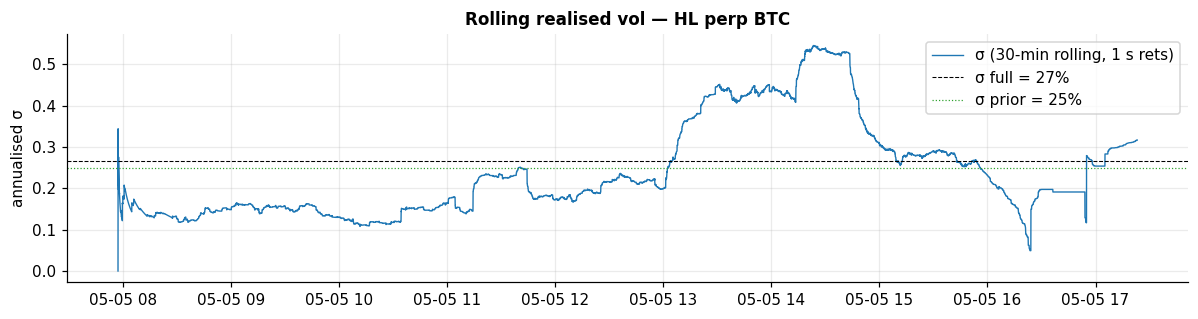

In [5]:
# 1-second log returns from HL perp BBO mid (separate finer grid → more data)
hl_fine = bbo_local_grid('hyperliquid','perp','BTC', freq='1s')['mid']
ret_1s = np.log(hl_fine).diff().dropna()
SEC_PER_YEAR = 365*24*3600

# rolling 30-min annualized sigma (median over 30-min window)
sigma_rolling = (ret_1s.rolling('30min').std() * np.sqrt(SEC_PER_YEAR))
sigma_full    = float(ret_1s.std() * np.sqrt(SEC_PER_YEAR))
print(f'σ (full window) ≈ {sigma_full:.2%}')

fig, ax = plt.subplots(figsize=(11,3))
ax.plot(sigma_rolling, lw=0.9, label='σ (30-min rolling, 1 s rets)')
ax.axhline(sigma_full, color='k', ls='--', lw=0.7, label=f'σ full = {sigma_full:.0%}')
ax.axhline(0.25,        color='C2', ls=':', lw=0.8, label='σ prior = 25%')
ax.set_ylabel('annualised σ'); ax.legend(); ax.set_title('Rolling realised vol — HL perp BTC')
plt.tight_layout(); plt.show()

## 4. Theoretical YES = Φ(d₂)

Compute the theo using each of the three σ choices, on the same 5-second grid
as the market mids.

In [6]:
sigma_roll_5s = sigma_rolling.reindex(g.index, method='ffill').bfill()
tau = np.asarray((T_exp - g.index).total_seconds() / SEC_PER_YEAR, dtype=float)
tau = np.clip(tau, 1e-9, None)
S_arr = g['S'].values

def theo(sig, S_arr, K, tau):
    sig = np.asarray(sig); tau = np.asarray(tau)
    d2 = (np.log(S_arr/K) - 0.5*sig**2*tau) / (sig*np.sqrt(tau))
    return norm.cdf(d2)

g['theo_roll']  = theo(sigma_roll_5s.values, S_arr, K, tau)
g['theo_full']  = theo(np.full_like(S_arr, sigma_full),   S_arr, K, tau)
g['theo_25']    = theo(np.full_like(S_arr, 0.25),         S_arr, K, tau)
g['mkt_yes_via_no'] = 1 - g['mid_no']
g[['S','mid_yes','mkt_yes_via_no','theo_roll','theo_full','theo_25']].tail()

,S,mid_yes,mkt_yes_via_no,theo_roll,theo_full,theo_25
t,,,,,,
2026-05-05 17:22:40+00:00,81401.5,0.682405,0.682250,0.683816,0.715007,0.728207
2026-05-05 17:22:45+00:00,81397.5,0.681290,0.681110,0.682329,0.713370,0.726498
2026-05-05 17:22:50+00:00,81397.5,0.681290,0.683075,0.682302,0.713381,0.726509
2026-05-05 17:22:55+00:00,81376.5,0.680195,0.683075,0.674604,0.704662,0.717398
2026-05-05 17:23:00+00:00,81376.5,0.680195,0.682910,0.673879,0.704673,0.717409


## 5. The chart you asked for — theo vs actual, aligned on receive time

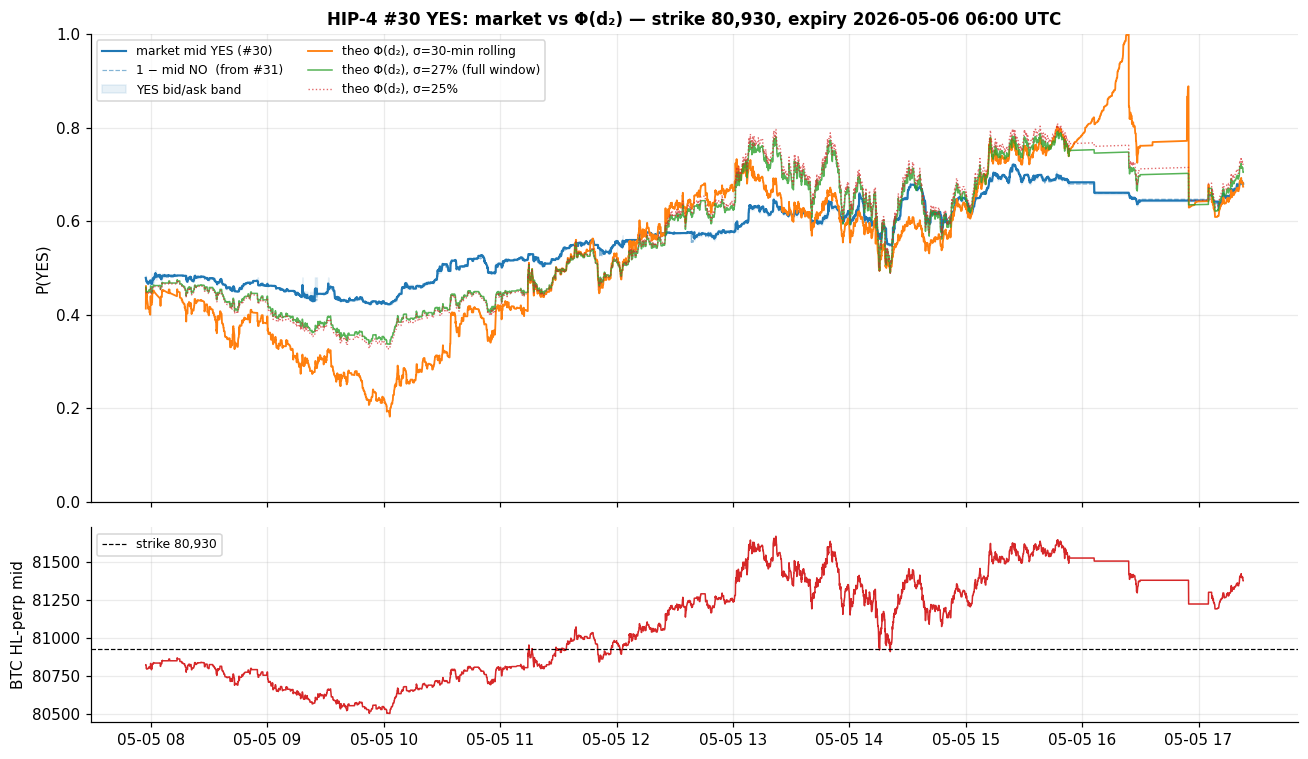

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios':[2.4, 1]})

ax = axes[0]
ax.plot(g.index, g['mid_yes'],         label='market mid YES (#30)', color='C0', lw=1.4)
ax.plot(g.index, g['mkt_yes_via_no'],  label='1 − mid NO  (from #31)', color='C0', lw=0.8, alpha=0.55, ls='--')
ax.fill_between(g.index, g['bid_yes'], g['ask_yes'], color='C0', alpha=0.10, label='YES bid/ask band')
ax.plot(g.index, g['theo_roll'],       label='theo Φ(d₂), σ=30-min rolling', color='C1', lw=1.2)
ax.plot(g.index, g['theo_full'],       label=f'theo Φ(d₂), σ={sigma_full:.0%} (full window)', color='C2', lw=1.0, alpha=0.8)
ax.plot(g.index, g['theo_25'],         label='theo Φ(d₂), σ=25%', color='C3', lw=0.9, alpha=0.7, ls=':')
ax.set_ylabel('P(YES)')
ax.set_ylim(0, 1)
ax.set_title(f'HIP-4 #30 YES: market vs Φ(d₂) — strike {K:,.0f}, expiry {T_exp:%Y-%m-%d %H:%M} UTC')
ax.legend(loc='upper left', fontsize=8, ncol=2)

# bottom panel: BTC perp mid with strike line
axes[1].plot(g.index, g['S'], color='C3', lw=1.0)
axes[1].axhline(K, color='k', ls='--', lw=0.8, label=f'strike {K:,.0f}')
axes[1].set_ylabel('BTC HL-perp mid')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout(); plt.show()

## 6. Residuals — where does the market disagree with the model?

Positive = market YES > theo (market over-pays for the upside);
negative = market YES < theo. A persistent sign tells you σ is mis-specified;
zero-mean noise tells you the model is the right shape.

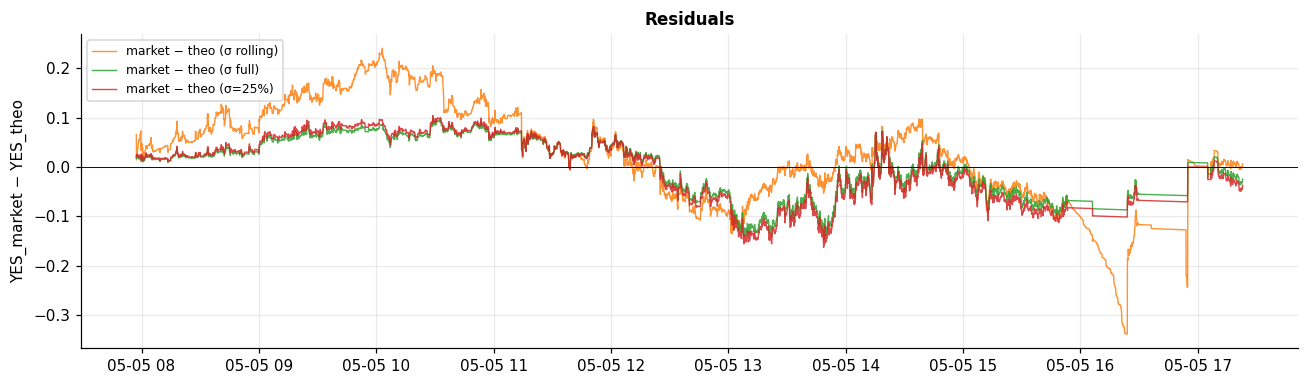

residual stats (price units):
  vs theo_roll  mean=+0.0225  std=0.1003  5%=-0.1271  95%=+0.1857
  vs theo_full  mean=-0.0029  std=0.0593  5%=-0.1011  95%=+0.0771
  vs theo_25    mean=-0.0073  std=0.0670  5%=-0.1134  95%=+0.0847


In [8]:
fig, ax = plt.subplots(figsize=(12, 3.6))
for col, lbl, c in [('theo_roll','market − theo (σ rolling)','C1'),
                    ('theo_full','market − theo (σ full)','C2'),
                    ('theo_25',  'market − theo (σ=25%)',  'C3')]:
    diff = g['mid_yes'] - g[col]
    ax.plot(g.index, diff, label=lbl, lw=0.9, color=c, alpha=0.85)
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('YES_market − YES_theo')
ax.set_title('Residuals'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

print('residual stats (price units):')
for col in ['theo_roll','theo_full','theo_25']:
    d = (g['mid_yes'] - g[col]).dropna()
    print(f'  vs {col:9s}  mean={d.mean():+.4f}  std={d.std():.4f}  '
          f'5%={d.quantile(0.05):+.4f}  95%={d.quantile(0.95):+.4f}')

## 7. Implied σ inverted from market YES

For each timestamp, solve `Φ(d₂(σ)) = YES_market` for σ. Cleaner signal than
the residual because it normalises for the position on the S-curve.

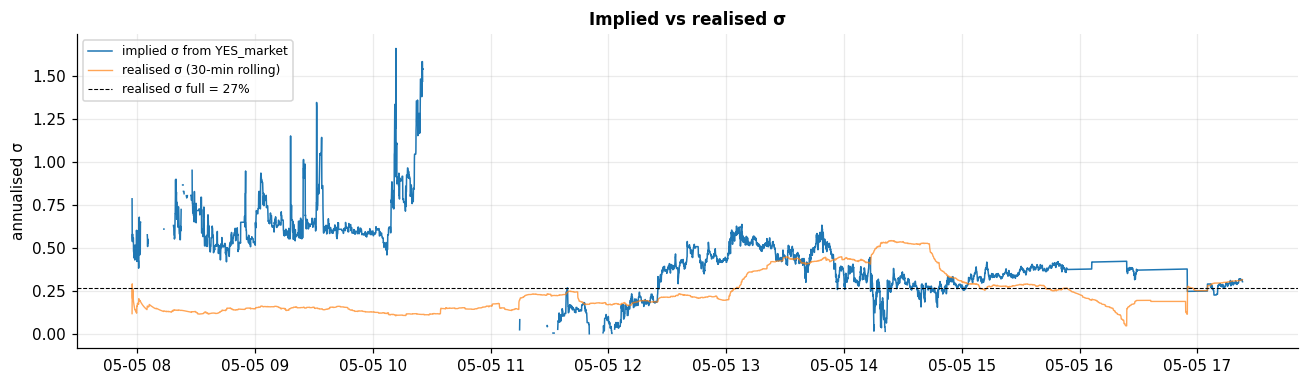

median implied σ = 39.26%   median realised (rolling) = 19.75%


In [9]:
def implied_vol_one(p_yes, S, K, tau):
    if not (0 < p_yes < 1) or tau <= 0 or S <= 0 or K <= 0: return np.nan
    target = norm.ppf(p_yes)  # = d2
    a = -0.5*tau; b = -target*np.sqrt(tau); c = np.log(S/K)
    disc = b*b - 4*a*c
    if disc < 0: return np.nan
    s1 = (-b + np.sqrt(disc))/(2*a); s2 = (-b - np.sqrt(disc))/(2*a)
    cands = [s for s in (s1, s2) if s and 0 < s < 5]
    return min(cands) if cands else np.nan

iv = np.array([
    implied_vol_one(p, s, K, t)
    for p, s, t in zip(g['mid_yes'].values, g['S'].values, tau)
])
g['impl_vol'] = iv

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(g.index, g['impl_vol'], lw=1.0, label='implied σ from YES_market')
ax.plot(sigma_rolling.reindex(g.index).index, sigma_rolling.reindex(g.index),
        lw=0.9, alpha=0.7, color='C1', label='realised σ (30-min rolling)')
ax.axhline(sigma_full, color='k', ls='--', lw=0.7, label=f'realised σ full = {sigma_full:.0%}')
ax.set_ylabel('annualised σ'); ax.set_title('Implied vs realised σ')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

print(f'median implied σ = {np.nanmedian(iv):.2%}   median realised (rolling) = {sigma_rolling.median():.2%}')

## 8. Reading the chart

- If **theo (σ rolling) tracks market YES tightly** → BS-digital + perp-mid is a
  decent fair value at this regime; passive MM on the binary can quote
  symmetric around theo and harvest the bid-ask.
- If **market sits persistently above theo** → either the market is using a
  higher σ than realized (priced uncertainty), or there's a settlement-rule
  premium / dust-tail mass we're not modelling (e.g. the binary settles off
  oracle which can deviate from perp mid; depeg / outage risk gets pushed into
  YES).
- **Implied vs realised σ** is the key panel for an MM: if implied is stable
  and persistently higher than realised (typical for short-dated binaries),
  selling YES spreads + delta-hedging on perp is a positive-EV trade modulo
  hedge cost.

For a real trading decision we'd want:
1. ≥1 full settlement cycle of data (06:00 UTC roll) so we see the post-jump
   re-pricing — currently still pre-roll.
2. Settlement source confirmed (the binary uses HL **oracle** at expiry, not
   the perp mid); for pricing the *settlement* we should use oracle, even
   though for *hedging* perp mid is cleaner.
3. A funding-aware drift term once the binary moves to multi-day expiries.